## 1. Conexión y carga de datos

Conectamos a la base SQLite del proyecto y cargamos en memoria las tablas `accidentes`, `clima` y `raw_accidentes`.

In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(r"../Datos/data_accidentes.sqlite3")

In [3]:
accidentes = pd.read_sql("SELECT * FROM accidentes", conn, parse_dates=["TW"])
clima = pd.read_sql("SELECT * FROM clima", conn, parse_dates=["TW"])
raw = pd.read_sql("SELECT * FROM raw_accidentes", conn, parse_dates=["TW"])

conn.close()

## 2. Diagnóstico inicial de la tabla `clima`

Primera mirada a los datos: muestra de filas, conteo de nulos por columna y tabla con el porcentaje de valores faltantes.

2.1 Muestra Inicial

In [ ]:
clima.head()

,TW,BARRIO,summary,icon,precipIntensity,precipProbability,temperature,apparentTemperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility
0,2017-01-01 00:00:00,aguasfrias,Partly Cloudy,partly-cloudy-night,0.0,0.0,16.43,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004
1,2017-01-01 01:00:00,aguasfrias,Partly Cloudy,partly-cloudy-night,0.0,0.0,16.43,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004
2,2017-01-01 02:00:00,aguasfrias,Foggy,fog,0.0,0.0,15.43,15.43,13.0,0.85,1.02,NaN,0.44,0.0,2.997
3,2017-01-01 03:00:00,aguasfrias,Foggy,fog,0.0,0.0,15.43,15.43,13.0,0.85,2.09,140.0,0.44,0.0,0.199
4,2017-01-01 04:00:00,aguasfrias,Foggy,fog,0.0,0.0,15.43,15.43,13.0,0.85,2.09,350.0,1.00,0.0,0.099


2.2 Porcentaje de Nulos por Cada Columna

In [11]:
nulos = clima.isnull().sum()
porcentaje = (nulos / len(clima) * 100).round(2)
pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": porcentaje})

,Nulos,Porcentaje (%)
TW,0,0.00
BARRIO,0,0.00
summary,548641,6.87
icon,548641,6.87
precipIntensity,547401,6.85
precipProbability,547401,6.85
temperature,610,0.01
apparentTemperature,610,0.01
dewPoint,305,0.00
humidity,915,0.01


## 3. Variables categóricas y duplicados

3.1 Exploraciones de las variables categoricas de icon y Summary 

In [8]:
valores_summary = clima["summary"].unique()
valores_icon = clima["icon"].unique()
print(valores_summary)
print("--------------------------------")
print("--------------------------------")
print("--------------------------------")
print(valores_icon)


<StringArray>
[                'Partly Cloudy',                         'Foggy',
                 'Mostly Cloudy',                         'Clear',
                      'Overcast',                             nan,
                       'Drizzle',                    'Light Rain',
                          'Rain',                    'Heavy Rain',
              'Possible Drizzle',           'Possible Light Rain',
       'Windy and Mostly Cloudy',       'Humid and Mostly Cloudy',
            'Humid and Overcast',       'Windy and Partly Cloudy',
                         'Windy',                'Rain and Windy',
                         'Humid', 'Possible Light Rain and Windy',
       'Humid and Partly Cloudy']
Length: 21, dtype: str
--------------------------------
--------------------------------
--------------------------------
<StringArray>
['partly-cloudy-night',                 'fog',   'partly-cloudy-day',
           'clear-day',              'cloudy',         'clear-night',
      

3.2 Exploración de de los Valores de Barrio 

In [10]:
barrios = clima["BARRIO"].dropna().unique()
print(f"Total valores únicos en BARRIO: {len(barrios)}\n")

for barrio in sorted(barrios, key=str):
    print(barrio)

Total valores únicos en BARRIO: 319

aguasfrias
aldeapablovi
alejandria
alejandroechavarria
alfonsolopez
altamira
altavista
altavistasectorcentral
altosdelpoblado
andalucia
antonionariño
aranjuez
areadeexpansionaltavista
areadeexpansionaltosdecalasanz
areadeexpansionbelenrincon
areadeexpansionpajarito
areadeexpansionsanantoniodeprado
asomaderano1
asomaderano2
asomaderano3
astorga
auresno1
auresno2
barriocaicedo
barriocolombia
barriocolon
barriocristobal
barriodejesus
barriosdejesus
batallongirardot
bcerroelvolador
belalcazar
belen
belencito
bellohorizonte
berlin
bermejal-losalamos
betania
blanquizal
bolivariana
bombonano1
bombonano2
bosquesdesanpablo
boston
boyaca
brasilia
buenosaires
bugapatiobonito
cabecerasanantoniodeprado
cabeceraurbanasancristobal
calasanz
calasanzpartealta
callenueva
campoalegre
campoamor
campovaldesno1
campovaldesno2
caribe
carloserestrepo
carpinelo
castilla
castropol
cataluña
cementeriouniversal
centroadministrativo
cerronutibara
corazondejesus
cordoba
corregim

3.3 Porcentaje de registros que no tienen el nombre del Barrio 

In [11]:
porcetanje=((clima["BARRIO"] == "sinnombre").sum()/len(clima["BARRIO"])*100).round(2)
print(f"Porcentaje de sinnombre: {porcetanje}%")

Porcentaje de sinnombre: 0.11%


## 4. EDA inicial 

4.1 Outliers

In [12]:
numericas = clima.select_dtypes(include="number")

Q1 = numericas.quantile(0.25)
Q3 = numericas.quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

out_inf = (numericas < lim_inf).sum()
out_sup = (numericas > lim_sup).sum()
total_out = out_inf + out_sup
porcentaje = (total_out / numericas.count() * 100).round(2)

resumen = pd.DataFrame({
    "Límite inferior": lim_inf.round(2),
    "Outliers (inf)": out_inf,
    "Límite superior": lim_sup.round(2),
    "Outliers (sup)": out_sup,
    "Total outliers": total_out,
    "Porcentaje (%)": porcentaje
}).sort_values("Total outliers", ascending=False)

resumen

,Límite inferior,Outliers (inf),Límite superior,Outliers (sup),Total outliers,Porcentaje (%)
precipIntensity,-0.91,0,1.51,775606,775606,10.42
windBearing,-47.50,0,244.50,642631,642631,9.23
windSpeed,-1.11,0,4.01,426405,426405,5.36
precipProbability,-0.39,0,0.65,327735,327735,4.40
dewPoint,8.82,38484,19.97,17299,55783,0.70
visibility,2.48,54931,22.55,0,54931,0.69
humidity,0.33,37767,1.16,0,37767,0.47
uvIndex,-6.00,0,10.00,24024,24024,0.30
apparentTemperature,8.32,401,31.17,769,1170,0.01
temperature,8.29,301,31.06,611,912,0.01


4.2 Histograma y Boxplot de windBearing

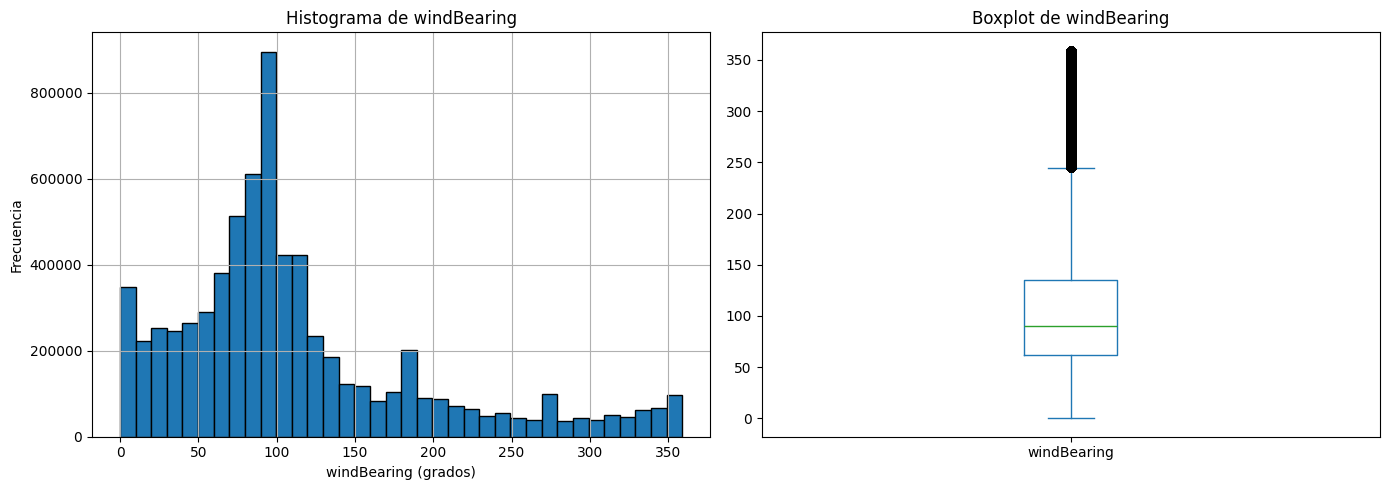

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clima["windBearing"].dropna().hist(bins=36, ax=axes[0], edgecolor="black")
axes[0].set_title("Histograma de windBearing")
axes[0].set_xlabel("windBearing (grados)")
axes[0].set_ylabel("Frecuencia")

clima["windBearing"].dropna().plot.box(ax=axes[1])
axes[1].set_title("Boxplot de windBearing")

plt.tight_layout()
plt.show()

4.3 Matriz de correlación

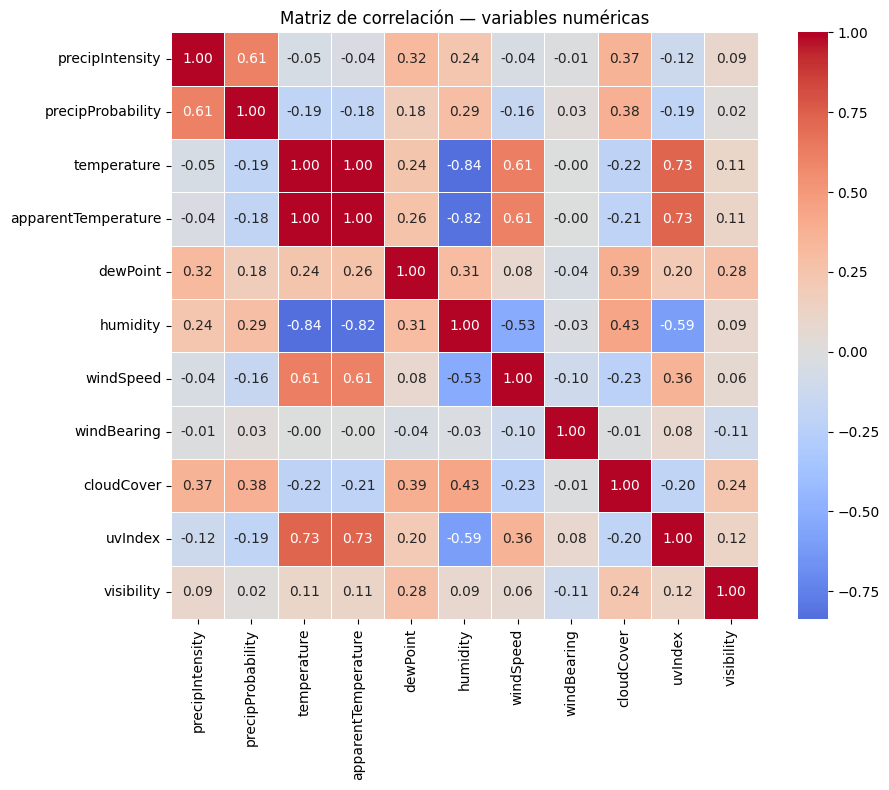

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

numericas = clima.select_dtypes(include="number")
corr = numericas.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Matriz de correlación — variables numéricas")
plt.tight_layout()
plt.show()

In [ ]:

import os

os.makedirs("Datos/csv", exist_ok=True)
accidentes.to_csv("Datos/csv/accidentes.csv", index=False, encoding="utf-8-sig")
clima.to_csv("Datos/csv/clima.csv", index=False, encoding="utf-8-sig")
raw.to_csv("Datos/csv/raw_accidentes.csv", index=False, encoding="utf-8-sig")

print("✅ Archivos CSV guardados correctamente")

KeyboardInterrupt: 

## 5. Resumen de hallazgos

Documento de cierre del diagnóstico exploratorio sobre `clima` (y carga de `accidentes` / `raw_accidentes` desde SQLite).

### Datos cargados

- Fuente: `../Datos/data_accidentes.sqlite3`.
- Tablas en memoria: `accidentes`, `clima`, `raw_accidentes` (con `TW` como fecha).
- El análisis detallado del notebook se centra en **`clima`** (~8 millones de filas). `accidentes` y `raw` se cargan pero no se diagnostican aquí.

### Calidad: valores faltantes

| Hallazgo | Detalle |
|----------|---------|
| Sin nulos | `TW` y `BARRIO` (0 %). |
| Bloque coherente de ausencia | `summary`, `icon`, `precipIntensity` y `precipProbability` comparten ~**6,85–6,87 %** de nulos (~548 mil filas). Sugiere registros sin respuesta completa del servicio meteorológico. |
| Mayor problema numérico | `windBearing` con **12,92 %** de nulos (~1,03 M filas), el campo más incompleto. |
| Nulos bajos | `temperature`, `apparentTemperature`, `dewPoint`, `humidity`, `cloudCover`, `uvIndex`, `visibility` (< 0,1 % en la mayoría). |
| Intermedio | `windSpeed` (~0,41 %). |

### Variables categóricas

- **`summary`**: 21 categorías (incluye `nan`); mezcla condiciones simples (“Clear”, “Foggy”) y compuestas (“Humid and Mostly Cloudy”, “Rain and Windy”).
- **`icon`**: 9 categorías (incluye `nan`); menos granular que `summary`; ambas columnas faltan en el mismo patrón de filas.
- **`BARRIO`**: **319** barrios distintos en Medellín y área metropolitana.
- **`sinnombre`**: solo **0,11 %** de los registros; volumen pequeño pero conviene filtrarlo o corregirlo antes del modelado.



### Outliers (método IQR, 1,5×)

Los porcentajes más altos (sobre filas no nulas por columna):

1. `precipIntensity` — **10,42 %** (casi todos por encima del límite superior; coherente con picos de lluvia).
2. `windBearing` — **9,23 %** (valores fuera del rango típico 0–360° en el criterio IQR).
3. `windSpeed` — **5,36 %**.
4. `precipProbability` — **4,40 %**.

`temperature` y `apparentTemperature` tienen muy pocos outliers (**0,01 %**). `cloudCover` no mostró outliers con este criterio.

### Distribución y correlaciones

- **`windBearing`**: histograma y boxplot muestran la dispersión direccional del viento en grados; la alta tasa de nulos limita la interpretación sin imputación o filtrado previo.
- **Matriz de correlación**: `temperature` y `apparentTemperature` están fuertemente relacionadas (esperable). Variables de precipitación y viento pueden correlacionarse entre sí en eventos de lluvia; revisar multicolinealidad si se usan juntas en modelos.
-También hay una correación importante entre Temperature y humidity de -84%

### Acciones recomendadas (alineadas con `LimpiezaClima.ipynb`)

1. Eliminar filas sin `summary` (bloque ~7 % de datos incompletos en categorías clave).
2. Imputar o tratar `windBearing` (mediana por la dispersión y outliers encontrados en esa columna); es la columna con más nulos.
3. Quitar registros con `BARRIO == "sinnombre"`.
4. Valorar eliminar `icon` y/o `apparentTemperature` si aportan poco frente a `summary` y `temperature`.
5. Revisar outliers de precipitación antes de descartarlos (pueden ser eventos reales).
6. Elimnar las filas con los nulos de lás demás filas porque no representan un proporción grande dentro de los datos.

---

